# Mini Project 3

By the deadline, please submit the provided Jupyter notebook with all/some required tasks completed and clearly solved. Make sure your code is neat, well-commented, and that all outputs are visible (run all cells before saving). Notebooks with missing tasks or unexecuted cells may receive fewer points. After you submit, you won’t be able to make changes, so double-check your work and be sure to start from the provided template

## Submission rules
As already discussed in class, we will stick to the following rules.
- Use the templates and name your files `NAME_SURNAME.ipynb` (If you have more than one name, just concatenate them). We will compare what you present with that file. 
- Code either not written in Python or not using PyTorch receives a grade of 0. Of course, you can use auxiliary packages when needed (`matplotlib`, `numpy`, ...), but for the learning part, you must use PyTorch.
-  If plagiarism is suspected, TAs and I will thoroughly investigate the situation, and we will summon the student for a face-to-face clarification regarding certain answers they provided. In case of plagiarism, a score reduction will be applied to all the people involved, depending on their level of involvement.
-  If extensive usage of AI tools is detected, we will summon the student for a face-to-face clarification regarding certain answers they provided. If the answers are not adequately supported with in-person answers, we will proceed to apply a penalty to the evaluation, ranging from 10% to 100%.

## Sentiment Analysis with LSTM

The IMDb dataset is a large collection of movie reviews compiled by the Internet Movie Database (IMDb), one of the most comprehensive online databases for films, TV shows, actors, and production crew information. IMDb is widely used for accessing details such as cast lists, user ratings, reviews, and plot summaries [(source)](https://www.geeksforgeeks.org/data-science/imdb-datasets-types-usages-and-application/).

In this mini-project, you will perform **sentiment analysis** on IMDb movie reviews using **LSTM-based models**. The goal is to classify each review as positive or negative.

You are required to build and train:

* A **simple LSTM model**, aiming for at least **75% test accuracy**
* A **more advanced LSTM model**, trying to push the accuracy as high as possible
* A **function** that can evaluate the sentiment of any new review

In [1]:
# Packages here 
from datasets import load_dataset
import torch
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence
import numpy as np
import pandas as pd
import re
from sklearn.model_selection import train_test_split
from collections import Counter
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import urllib.request
import zipfile
import os

# Don't change this 
torch.manual_seed(123)
torch.cuda.manual_seed(123)
np.random.seed(123)
torch.backends.cudnn.enabled=False
torch.backends.cudnn.deterministic=True

### Task 1 (0 pts)

To load the data, we will use [Hugging Face](https://huggingface.co/), an open-source platform that provides datasets, pre-trained models, and tools for modern machine learning.
**Note:** In principle, you could also use [TorchText](https://docs.pytorch.org/text/main/datasets.html#imdb), but it does not work reliably on Kaggle. Using PyTorch’s dataset instead of Hugging Face is **not** considered an error.

Inspect the dataset you load and make sure you understand its structure and format.

In [2]:
ds = load_dataset("stanfordnlp/imdb")
dataset_train = ds['train']
dataset_test = ds['test']

In [3]:
print(f"Train dataset size: {len(dataset_train)}")
print(f"Test dataset size: {len(dataset_test)}")
print() 
print(dataset_train.column_names)
print(dataset_test[0])

Train dataset size: 25000
Test dataset size: 25000

['text', 'label']
{'text': 'I love sci-fi and am willing to put up with a lot. Sci-fi movies/TV are usually underfunded, under-appreciated and misunderstood. I tried to like this, I really did, but it is to good TV sci-fi as Babylon 5 is to Star Trek (the original). Silly prosthetics, cheap cardboard sets, stilted dialogues, CG that doesn\'t match the background, and painfully one-dimensional characters cannot be overcome with a \'sci-fi\' setting. (I\'m sure there are those of you out there who think Babylon 5 is good sci-fi TV. It\'s not. It\'s clichéd and uninspiring.) While US viewers might like emotion and character development, sci-fi is a genre that does not take itself seriously (cf. Star Trek). It may treat important issues, yet not as a serious philosophy. It\'s really difficult to care about the characters here as they are not simply foolish, just missing a spark of life. Their actions and reactions are wooden and predictab

### Task 2 (5 pts)

Split the original **test set** into two parts: a **validation set** and a **final test set**. Use a split of 50-50.

**Note:** We are aware that, in a typical machine learning workflow, you would split the **training set** (not the test set) to create a validation set. However, in this exercise, we intentionally use the test set for this purpose to provide you with **more training data** for model learning.

In [4]:
df = dataset_test.to_pandas() #from hugface dataset to pandas dataframe
val_set, test_set = train_test_split(df, train_size=0.5, random_state=123)
print(f"Validation set size: {len(val_set)}")
print(f"Test set size: {len(test_set)}")    

Validation set size: 12500
Test set size: 12500


### Task 3 (10 pts)

Create a `tokenize` function that takes a line from your dataset (a review) and converts it into tokens.
You may want to consider the following:

* Are `film` and `film.` considered different?
* Does it matter if a word is uppercase or lowercase?
* Should tokens like `<br />` be included or removed?

In [5]:
def tokenize(line):
    # lowercase
    line = line.lower()
    
    # remove html tags like <br />
    line = re.sub(r"<.*?>", " ", line)
    
    # replace punctuation with spaces, keep only letters and numbers
    line = re.sub(r"[^a-z0-9!]+", " ", line) #i ve added also esclamation marks as they seem pretty useful for sentiment analysis if you think about it!
    
    # split into tokens
    tokens = line.strip().split()
    
    return tokens
# i ll call it later

### Task 4 (5 pts)
Create two dictionaries, `word_to_idx` and `idx_to_word`, to map words to their embedding indices and vice versa. At this stage, you should decide whether to remove outlier words and replace them with the `<UNK>` token. This decision will, of course, depend on the performance you observe afterward.

In [6]:

def build_vocab(dataset, tokenize_fn, min_freq=5, max_vocab_size=None):
    """
    Build vocabulary with fixed reserved tokens at indices 0 and 1.
    """

    # Fixed initialization
    word_to_idx = {'<PAD>': 0, '<UNK>': 1}
    idx_to_word = {0: '<PAD>', 1: '<UNK>'}
    next_idx = 2

    # 1. Count tokens
    counter = Counter()
    for item in tqdm(dataset, desc="Counting tokens"):
        tokens = tokenize_fn(item["text"])
        counter.update(tokens)

    # 2. Filter by min_freq
    if min_freq is not None:
        counter = Counter({w: c for w, c in counter.items() if c >= min_freq})

    # 3. Sort tokens by descending frequency (then alphabetically for determinism)
    sorted_tokens = sorted(counter.items(), key=lambda x: (-x[1], x[0]))

    # 4. Apply maximum vocabulary size if needed
    if max_vocab_size is not None:
        # subtract 2 because PAD and UNK already exist
        sorted_tokens = sorted_tokens[:max_vocab_size - 2]

    # 5. Insert into dictionaries
    for tok, freq in sorted_tokens:
        if tok not in word_to_idx:
            word_to_idx[tok] = next_idx
            idx_to_word[next_idx] = tok
            next_idx += 1

    return word_to_idx, idx_to_word, counter



In [7]:
min_freq = 5
max_vocab_size = 20000

word_to_idx, idx_to_word, token_counts = build_vocab(
    dataset_train,
    tokenize_fn=tokenize,
    min_freq=min_freq,
    max_vocab_size=max_vocab_size
)

print("Vocab size:", len(word_to_idx))
print("First entries:", word_to_idx)
print("Top 10 tokens:", token_counts.most_common(10))

Counting tokens:   0%|          | 0/25000 [00:00<?, ?it/s]

Vocab size: 20000
First entries: {'<PAD>': 0, '<UNK>': 1, 'the': 2, 'and': 3, 'a': 4, 'of': 5, 'to': 6, 'is': 7, 'it': 8, 'in': 9, 'i': 10, 'this': 11, 'that': 12, 's': 13, 'was': 14, 'as': 15, 'for': 16, 'with': 17, 'movie': 18, 'but': 19, 'film': 20, 't': 21, 'you': 22, 'on': 23, 'not': 24, 'he': 25, 'are': 26, 'his': 27, 'have': 28, 'be': 29, 'one': 30, 'all': 31, 'at': 32, 'they': 33, 'by': 34, 'an': 35, 'who': 36, 'so': 37, 'from': 38, 'like': 39, 'there': 40, 'her': 41, 'or': 42, 'just': 43, 'about': 44, 'out': 45, 'if': 46, 'has': 47, 'what': 48, 'some': 49, 'good': 50, 'can': 51, 'she': 52, 'more': 53, 'when': 54, 'very': 55, 'up': 56, 'no': 57, 'even': 58, 'time': 59, 'my': 60, 'would': 61, 'which': 62, 'story': 63, 'only': 64, 'really': 65, 'see': 66, 'their': 67, 'had': 68, 'we': 69, 'were': 70, 'me': 71, 'well': 72, 'than': 73, 'much': 74, 'get': 75, 'been': 76, 'people': 77, 'bad': 78, 'will': 79, 'other': 80, 'also': 81, 'do': 82, 'into': 83, 'first': 84, 'because': 85, '

### Task 5 (10 pts)
Create a `Dataset` class. The `__getitem__` function should return `(X, y)`, where `X` is a tensor containing the indices of the embedded words, and `y` is a tensor representing the sentiment expressed in the review.


In [8]:
class DatasetIMDB(torch.utils.data.Dataset):
    def __init__(self, dataset, word_to_idx, text_col="text", label_col="label", tokenize_fn=tokenize):
        """
        Args:
            dataset: HuggingFace dataset split or pandas DataFrame containing the data
            word_to_idx: dict mapping tokens to indices, must contain '<UNK>'
            text_col: name of the text column (default "text")
            label_col: name of the label column (default "label")
            tokenize_fn: function to turn a text string into a list of tokens
        """
        self.dataset = dataset
        self.word_to_idx = word_to_idx
        self.text_col = text_col
        self.label_col = label_col
        self.tokenize_fn = tokenize_fn
        if '<UNK>' not in self.word_to_idx:
            raise ValueError("word_to_idx must contain '<UNK>' token")

        # detect whether dataset is pandas DataFrame or HuggingFace dataset
        self._is_pandas = hasattr(dataset, "iloc") and hasattr(dataset, "to_dict")

    def __len__(self):
        return len(self.dataset)

    def _get_row(self, idx):
        if self._is_pandas:
            row = self.dataset.iloc[idx]
            text = row[self.text_col]
            label = row[self.label_col]
        else:
            # assume HuggingFace dataset-style indexing
            item = self.dataset[idx]
            text = item[self.text_col]
            label = item[self.label_col]
        return text, label

    def __getitem__(self, idx):
        text, label = self._get_row(idx)
        tokens = self.tokenize_fn(text)
        unk_idx = self.word_to_idx.get('<UNK>', 1)
        indices = [self.word_to_idx.get(t, unk_idx) for t in tokens]
        # Return X as 1D LongTensor and y as scalar LongTensor
        X = torch.tensor(indices, dtype=torch.long)
        y = torch.tensor(int(label), dtype=torch.long)
        return X, y

In [9]:
def collate(batch):
    # batch is a list of tuples (sequence, label)
    # where sequence is already numericalized
    
    sequences, labels = zip(*batch)#now when looped over it loop over them together and with * before it unpacks it giving one obj of each

    # sequences is a list of 1D LongTensors
    sequences_padded = pad_sequence(
        sequences,
        batch_first=True,
        padding_value=0   # PAD index
    )

    labels = torch.stack(labels)

    return sequences_padded, labels


### Task 7 (5 pts)

Create one `DataLoader` for each dataset: Training, Validation, and Test. Make sure each `DataLoader` uses your `Dataset` class and the `collate_fn` function you defined in Task 6.

In [10]:

batch_size = 64
num_workers = 0 #no parallelism

# Dataset instances
ds_train = DatasetIMDB(dataset_train, word_to_idx)         # HuggingFace split
ds_val   = DatasetIMDB(val_set.reset_index(drop=True), word_to_idx)   # pandas DataFrame
ds_test  = DatasetIMDB(test_set.reset_index(drop=True), word_to_idx)  # pandas DataFrame

# DataLoaders
train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True,
                          collate_fn=collate, num_workers=num_workers, pin_memory=True)
val_loader   = DataLoader(ds_val,   batch_size=batch_size, shuffle=False,
                          collate_fn=collate, num_workers=num_workers, pin_memory=True)
test_loader  = DataLoader(ds_test,  batch_size=batch_size, shuffle=False,
                          collate_fn=collate, num_workers=num_workers, pin_memory=True)

# Quick sanity check
for name, loader in [("train", train_loader), ("val", val_loader), ("test", test_loader)]:
    X_batch, y_batch = next(iter(loader))
    print(f"{name} batch X shape: {X_batch.shape}, y shape: {y_batch.shape}")


train batch X shape: torch.Size([64, 891]), y shape: torch.Size([64])
val batch X shape: torch.Size([64, 877]), y shape: torch.Size([64])
test batch X shape: torch.Size([64, 861]), y shape: torch.Size([64])


/opt/miniconda3/envs/averageML/lib/python3.10/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


### Task 8 (15 pts)

Define an `LSTM` class that can be customized as needed. Follow the provided template, but feel free to add additional attributes or methods if necessary.

In [ ]:
class LSTM(torch.nn.Module):
    def __init__(
        self,
        vocab_size,
        emb_dim=100,
        hidden_dim=128,
        num_layers=1,
        dropout=0.0,
        bidirectional=False
    ):
        super().__init__()

        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.bidirectional = bidirectional

        # Embedding layer
        self.embedding = torch.nn.Embedding(
            vocab_size,
            emb_dim,
            padding_idx=0
        )

        # LSTM layer
        self.lstm = torch.nn.LSTM(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0, #for one layer it shouldnt overfit anyway
            batch_first=True, #this is cause if your input data is of shape (batch_size, seq_len, features) 
            #then you need =True and your LSTM will give output of shape (batch_size, seq_len, hidden_size).
            bidirectional=bidirectional #looking at the sentence from both directions, symmetric approach to check for relationships that go from end to top as well
        )

        # Output dimension depends on bidirectionality
        lstm_out_dim = hidden_dim * 2 if bidirectional else hidden_dim

        # Final classifier
        self.fc = torch.nn.Linear(lstm_out_dim, 1)

    def forward(self, x, hidden=None):
        """
        x: (batch_size, seq_len)
        hidden: (h_0, c_0) or None
        """
        x = self.embedding(x)

        output, hidden = self.lstm(x, hidden)

        if self.bidirectional:
            h_forward = hidden[0][-2]
            h_backward = hidden[0][-1]
            h = torch.cat((h_forward, h_backward), dim=1)
        else:
            h = hidden[0][-1]

        logits = self.fc(h).squeeze(1)
        return logits, hidden
 

### Task 9 (30 pts)

Train your model. Aim for a **test** accuracy of at least 75%. Be prepared to answer, among others, the following questions:

* Did you use a stacked LSTM? Why or why not?
No, I used a single-layer LSTM, meaning num_layers = 1. This is because the task is usually considered pretty easy, LSTM are quite powerful and running too many hyperparameters would increase 1. Risk of overfitting when not regularizing a lot 2. Training time.
* Did you use a bidirectional LSTM? Why or why not?
Yes, I used a bidirectional LSTM by setting bidirectional = True . The motivation is that sentiment often depends on both preceding and following context within a sentence.
* Did you need to adjust tensor dimensions for your model?
Yes, I had to explicitly manage tensor dimensions, especially because of batching and bidirectionality. batch_first = true takes care of that
* Which loss function did you choose, and why?
Binary cross entropy with logits, It combines a sigmoid activation with binary cross-entropy in a single
Plot the training and evaluation losses, making sure there are no signs of overfitting, and print the final tarining/validation/test accuracy.

In [12]:
#using macbook gpu, better thing would be to run some fallbacks options so it can run on multiple devices without using cou
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)


Using device: mps


In [13]:
#---------SETUP------------
vocab_size = len(word_to_idx)

model = LSTM(
    vocab_size=vocab_size,
    emb_dim=100,
    hidden_dim=128,
    num_layers=1,
    dropout=0.0,
    bidirectional=True
)

model = model.to(device)
criterion = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 6 #usually for hyperparam it's better to do a dedicate cell at start with initialized values and try different ones from there 
#but i'm following the notebook flow
clip_value = 5.0


In [14]:
#--------------Accuracy Helper-----------------
def compute_accuracy(logits, labels):
    probs = torch.sigmoid(logits)
    preds = (probs >= 0.5).long()
    return (preds == labels).float().mean().item()

In [15]:
#------------Traning-----------------
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()

    total_loss = 0.0
    total_acc = 0.0
    num_batches = 0

    for X, y in loader:
        X = X.to(device)
        y = y.to(device).float()

        optimizer.zero_grad()

        logits, _  = model(X)
        loss = criterion(logits, y)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), clip_value)

        optimizer.step()

        acc = compute_accuracy(logits.detach(), y)

        total_loss += loss.item()
        total_acc += acc
        num_batches += 1

    return total_loss / num_batches, total_acc / num_batches


In [16]:
#---------EVAL-------------
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_acc = 0.0
    num_batches = 0

    for X, y in loader:
        X = X.to(device)
        y = y.to(device).float()

        logits, _  = model(X)
        loss = criterion(logits, y)

        acc = compute_accuracy(logits, y)

        total_loss += loss.item()
        total_acc += acc
        num_batches += 1

    return total_loss / num_batches, total_acc / num_batches


In [17]:
#---------Training Loop-------
train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(1, num_epochs + 1): #n loops
    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion, device
    ) #<-one loop

    val_loss, val_acc = evaluate(
        model, val_loader, criterion, device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(
        f"Epoch {epoch:02d} | "
        f"Train loss {train_loss:.4f}, acc {train_acc:.4f} | "
        f"Val loss {val_loss:.4f}, acc {val_acc:.4f}"
    )


/opt/miniconda3/envs/averageML/lib/python3.10/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 01 | Train loss 0.6772, acc 0.5669 | Val loss 0.6566, acc 0.6006
Epoch 02 | Train loss 0.5918, acc 0.6835 | Val loss 0.5897, acc 0.6896
Epoch 03 | Train loss 0.5122, acc 0.7555 | Val loss 0.5642, acc 0.7122
Epoch 04 | Train loss 0.4434, acc 0.8034 | Val loss 0.5209, acc 0.7525
Epoch 05 | Train loss 0.4045, acc 0.8265 | Val loss 0.4621, acc 0.7975
Epoch 06 | Train loss 0.3268, acc 0.8681 | Val loss 0.4140, acc 0.8245


In [18]:
#--------Test eval---------
test_loss, test_acc = evaluate(
    model, test_loader, criterion, device
)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")


Test loss: 0.4224
Test accuracy: 0.8209


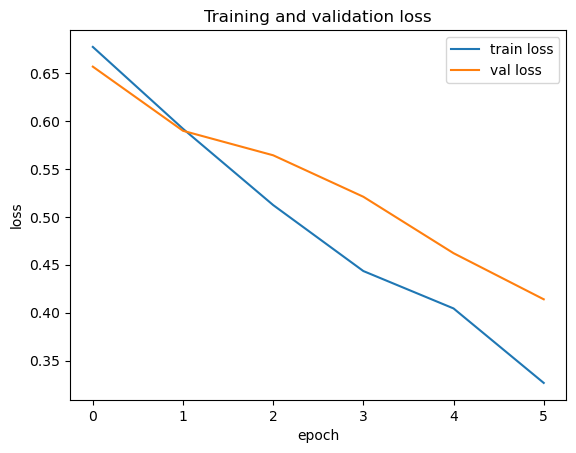

In [19]:
#-----------Plotting Loss/ checking overfit-------------

plt.figure()
plt.plot(train_losses, label="train loss")
plt.plot(val_losses, label="val loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.title("Training and validation loss")
plt.show()


### Task 10 (5 pts)

Improve your model architecture and training procedure by applying one or more of the following strategies:

* Truncated Backpropagation Through Time
* Better tokenizer
* Pre-trained embeddings
* ....

This exercise is considered successful if **any "sensible" improvement in test accuracy** is achieved, even by applying just one change.

In [20]:
# Try 1 is Pre-trained embeddings as it most likely improve performance and solve the task alone
# Honestly i know world2vec better but i ve just read Glove is similar and perform better on sentiment analysis/semantic tasks compared to syntactic task being more a word2vec thing so i ll try that
# Only problem is that you ll have to download the glove.txt, but i ll provide a cell for doing that. 

In [21]:
# -------- Download GloVe --------
#(even running more that once shouldnt download stuff again) 


def download_and_extract_glove(
    url="https://nlp.stanford.edu/data/glove.6B.zip", #i got this link as it seems a bit faster but there's also github repo glove embeddings.
    zip_path="glove.6B.zip",
    extract_dir="glove"
):
    if not os.path.exists(zip_path):
        print("Downloading GloVe...")
        urllib.request.urlretrieve(url, zip_path)
        print("Download completed.")
    else:
        print("GloVe zip already exists.")

    if not os.path.exists(extract_dir):
        print("Extracting GloVe...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_dir)
        print("Extraction completed.")
    else:
        print("GloVe already extracted.")

# run
download_and_extract_glove()


GloVe zip already exists.
GloVe already extracted.


In [22]:
# -------- Load GloVe embeddings --------

def load_glove_embeddings(glove_path, emb_dim=100):
    """
    Load GloVe embeddings from file.
    Returns a dict: word -> embedding vector
    """
    embeddings = {}
    with open(glove_path, "r", encoding="utf-8") as f:
        for line in f:
            values = line.rstrip().split(" ")
            word = values[0]
            vector = np.asarray(values[1:], dtype=np.float32)
            if vector.shape[0] == emb_dim:
                embeddings[word] = vector
    return embeddings
glove_path = os.path.join("glove", "glove.6B.100d.txt")  # adjust path if you got the embeddings somewhere else
glove_embeddings = load_glove_embeddings(glove_path, emb_dim=100)

print("Loaded GloVe vectors:", len(glove_embeddings))

Loaded GloVe vectors: 400000


In [23]:
# -------- Build embedding matrix --------

emb_dim = 100
vocab_size = len(word_to_idx)

embedding_matrix = np.random.normal(
    scale=0.6,
    size=(vocab_size, emb_dim)
).astype(np.float32)

found = 0
for word, idx in word_to_idx.items():
    if word in glove_embeddings:
        embedding_matrix[idx] = glove_embeddings[word]
        found += 1

print(f"Words with pretrained embeddings: {found}/{vocab_size}")


Words with pretrained embeddings: 19604/20000


In [24]:
# -------- Initialize model with GloVe --------

model = LSTM(
    vocab_size=vocab_size,
    emb_dim=emb_dim,
    hidden_dim=128,
    num_layers=1,
    dropout=0.0,
    bidirectional=True
)

# load pretrained embeddings
model.embedding.weight.data.copy_(torch.from_numpy(embedding_matrix))

# freeze embeddings
model.embedding.weight.requires_grad = False #embeddings are used fixed.

model = model.to(device)


In [25]:
#---------Setup-------
criterion = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),#for now no optimization of the embeddings
    lr=1e-3
)
#repetita juvant
num_epochs = 6
clip_value = 5.0


By now i've realized that in the dataset there are very long sequences which create quite a mess, so im now also implementing Truncated Backpropagation Through Time as it should help with the numerical instability

In [26]:
#Truncated Backpropagation Through Time
def train_one_epoch_tbptt(
    model,
    loader,
    optimizer,
    criterion,
    device,
    tbptt_step=100
):
    model.train()

    total_loss = 0.0
    total_acc = 0.0
    num_batches = 0

    for X, y in loader:
        X = X.to(device)
        y = y.to(device).float()

        batch_size, seq_len = X.size()

        hidden = None
        optimizer.zero_grad()

        # iterate over time chunks
        for t in range(0, seq_len, tbptt_step):
            x_chunk = X[:, t:t + tbptt_step]

            logits, hidden = model(x_chunk, hidden)

            loss = criterion(logits, y)
            loss.backward()

            # detach hidden state to truncate gradients
            hidden = (hidden[0].detach(), hidden[1].detach())

        torch.nn.utils.clip_grad_norm_(model.parameters(), clip_value)
        optimizer.step()

        acc = compute_accuracy(logits.detach(), y)

        total_loss += loss.item()
        total_acc += acc
        num_batches += 1

    return total_loss / num_batches, total_acc / num_batches



In [27]:
#-----------Training loop---------
#I'm using the same helpers, i knew they d come in handy for more than one model ;)
train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_one_epoch_tbptt(
        model, train_loader, optimizer, criterion, device
    )

    val_loss, val_acc = evaluate(
        model, val_loader, criterion, device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(
        f"Epoch {epoch:02d} | "
        f"Train loss {train_loss:.4f}, acc {train_acc:.4f} | "
        f"Val loss {val_loss:.4f}, acc {val_acc:.4f}"
    )


Epoch 01 | Train loss 0.6933, acc 0.4993 | Val loss 0.5853, acc 0.7221
Epoch 02 | Train loss 0.6424, acc 0.5853 | Val loss 0.4431, acc 0.7910
Epoch 03 | Train loss 0.4008, acc 0.8273 | Val loss 0.3804, acc 0.8271
Epoch 04 | Train loss 0.3462, acc 0.8557 | Val loss 0.3455, acc 0.8472
Epoch 05 | Train loss 0.3213, acc 0.8677 | Val loss 0.2978, acc 0.8754
Epoch 06 | Train loss 0.3044, acc 0.8738 | Val loss 0.2899, acc 0.8807


In [28]:
#--------Test eval---------
test_loss, test_acc = evaluate(
    model, test_loader, criterion, device
)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")


Test loss: 0.2879
Test accuracy: 0.8824


### Task 11 (5 pts)

Use one of your trained models to perform sentiment analysis on the following reviews. Be prepared to explain any issues you encountered and how you addressed them.

In [30]:
REVIEW_TEXT = """
Iron Man isn't just a superhero movie. It's the spark that ignited the entire Marvel Cinematic Universe. With Robert Downey Jr.'s career-defining performance, razor-sharp writing, and a perfect blend of heart, humor, and high-tech spectacle, this film redefined what a comic book movie could be.

Even after more than a decade, Iron Man remains one of the most re-watchable, charming, and influential superhero origin stories ever made.

🎬 Overview

Iron Man introduces Tony Stark (Robert Downey Jr.), a brilliant but arrogant billionaire weapons manufacturer. When he's captured by terrorists in Afghanistan and forced to build a missile, Tony instead constructs a powered suit of armor to escape.

Haunted by the destruction caused by his weapons, Stark returns home determined to reinvent himself. Not as a war profiteer, but as Iron Man, a hero powered by his mind, conscience, and an arc reactor in his chest.

Along the way, he faces betrayal from within his company, moral dilemmas, and a growing awareness of what true responsibility means.

✅ What Worked

1. Robert Downey Jr.: Perfect casting. His charisma, wit, and emotional depth made Tony Stark unforgettable.

2. Grounded realism: The technology feels just believable enough to make Iron Man's world plausible.

3. Sharp writing and humor: Smart, fast-paced dialogue that balances action with personality.

4. Emotional arc: Tony's transformation from egocentric arms dealer to self-aware hero feels authentic.

5. Cinematography & effects: The first suit build and flight sequences are still jaw-dropping.

6. Gwyneth Paltrow & Jeff Bridges: Excellent supporting cast. Pepper Potts' loyalty and Obadiah Stane's menace both shine.

7. The ending line: That bold, improvised moment "I am Iron Man." changed superhero cinema forever.

❌ What Didn't Work

1. Final battle pacing: The showdown between Iron Man and Iron Monger feels slightly rushed.

2. Limited female representation: Pepper is great, but she's one of very few women in a male-dominated cast.

3. Predictable villain motivation: Stane's greed is a bit by-the-numbers.

But honestly. These are small cracks in an otherwise near-perfect armor.

💬 Favorite Quotes / Moments

"I am Iron Man." - Tony Stark "Sometimes you've gotta run before you can walk." - Tony Stark "My turn." - Tony, before launching a missile at a tank "Is it better to be feared or respected? I say, is it too much to ask for both?" - Tony Stark Tony's first cave suit escape: gritty, powerful, and unforgettable.

The Mark II flight test: pure cinematic joy as Tony takes to the skies.

Pepper replacing Tony's arc reactor: both funny and intimate.

The press conference ending: Tony discarding the superhero secrecy trope in one iconic line.

The post-credit scene: Nick Fury's appearance teasing the Avengers Initiative (and the MCU as we know it).

💡 Fun Facts

1. Robert Downey Jr. Was not Marvel's first choice but his audition blew everyone away.

2. Much of the film's dialogue was improvised, including "I am Iron Man."

3. The movie was Marvel Studios' first independent production, made before Disney bought them.

4. Jon Favreau insisted on using practical effects for the suits wherever possible.

5. The success of Iron Man directly led to the creation of the MCU, which has since become the highest-grossing franchise in film history.

6. Tony Stark's mansion was CGI. It doesn't actually exist!

🎥 If You Liked This, You Might Also Enjoy

1. The Dark Knight (2008): Another intelligent and grounded superhero reboot.

2. Iron Man 2 (2010): The next chapter in Tony Stark's evolution.

3. Doctor Strange (2016): A spiritual successor exploring genius and redemption.

4. Captain America: The First Avenger (2011): Marvel's other essential origin story.

5. The Social Network (2010): Not a superhero movie, but a study of brilliance and ego that echoes Stark's early character.

Final Thoughts

Iron Man remains the gold standard for superhero origin stories. A perfect fusion of innovation, attitude, and emotion. It's not just about a man in a suit; it's about a man who learns to use his mind and heart for something greater.

Final Verdict: (9.5/10). "The birth of Iron Man was also the birth of a cinematic universe and it still flies higher than ever."
"""

In [31]:
@torch.no_grad()
def predict_sentiment(
    text,
    model,
    word_to_idx,
    tokenize_fn,
    device,
    threshold=0.5
):
    model.eval()

    # tokenize
    tokens = tokenize_fn(text)

    # numericalize
    unk_idx = word_to_idx.get("<UNK>", 1)
    indices = [word_to_idx.get(tok, unk_idx) for tok in tokens]

    # convert to tensor and add batch dimension
    X = torch.tensor(indices, dtype=torch.long).unsqueeze(0).to(device)

    # forward pass
    logits, _ = model(X)
    prob = torch.sigmoid(logits).item()

    label = "positive" if prob >= threshold else "negative"

    return label, prob


In [32]:
label, prob = predict_sentiment(
    text=REVIEW_TEXT,
    model=model,
    word_to_idx=word_to_idx,
    tokenize_fn=tokenize,
    device=device
)

print(f"Predicted sentiment: {label}")
print(f"Positive probability: {prob:.4f}")


Predicted sentiment: positive
Positive probability: 0.9882


## Questions

During the presentation, we may ask questions to ensure you have understood the core concepts of the course. Examples include:

1.	What is the hidden state in a recurrent neural network (RNN), and what role does it play during sequence processing?
It’s a memory vector that carries information from previous time steps
2.	Why do we need padding when working with batches of variable-length sequences? How is padding typically handled in practice?
Padding ensures all sequences in a batch have the same length; in practice, masked positions are ignored during computation to avoid affecting learning.
3.	What is a stacked RNN, and why might stacking multiple recurrent layers improve performance?
Multiple RNN layers stacked on top of each other; deeper layers can capture more complex patterns.
4.	What is a bidirectional RNN, and in which scenarios does it provide an advantage?
Processes sequences both forward and backward, providing context from past and future; useful in tasks like NLP where future context matters
5.	What is the exploding gradient problem in recurrent networks?
Gradients grow exponentially during backpropagation, causing instability and large updates that can break training.
6.	What is the vanishing gradient problem, and why is it particularly severe in RNNs?
Gradients shrink exponentially, preventing the network from learning long-range dependencies; severe in RNNs due to repeated multiplications through time steps.
7.	What is gradient clipping, and why is it commonly applied when training RNNs?
Limits the magnitude of gradients during training to prevent exploding gradients, stabilizing RNN learning.
8.	How do different activation functions influence vanishing or exploding gradients in deep or recurrent networks?
Functions like tanh or sigmoid can cause vanishing gradients, while ReLU can reduce vanishing but may increase exploding gradients. check derivative max and codomain
9.	What is truncated backpropagation through time, and why is it used when training RNNs?
Backpropagates gradients over a limited number of time steps to reduce memory usage and mitigate vanishing/exploding gradients.
10.	What is one-hot encoding for representing words in a vocabulary? What are its limitations?
Represents each word as a vector with one “1” and rest “0”; limited by high dimensionality and no semantic similarity between words.
11.	What does `nn.Embedding` do, and why is it preferred over one-hot encoding?
Learns dense vector representations for discrete tokens, capturing semantic relationships and reducing dimensionality compared to one-hot encoding.
12.	What are gating mechanisms in recurrent architectures (e.g., LSTM/GRU), and why are they important?
Structures like LSTM/GRU gates control information flow in/out of memory, enabling selective retention and forgetting of sequence information.
13.	How do LSTM gates help mitigate the vanishing gradient problem?
the derivative of cell state wrt previous state is just the value of forget gate.
the cell state provides a nearly linear path through time for gradients, gated by learnable sigmoids, which mitigates vanishing gradients and lets LSTMs remember long-term dependencies.


notes:
only use last hidden state, not last output token (obv).
accuracy is computed averaged on batch, could have been done per sample too (even better but)